# DeepXDE Inverse PINN for Robot Joint Motor Housing
Name: 안형준
Student ID: 20221250

This notebook implements a DeepXDE-based inverse PINN for a 1D transient motor-housing thermal model.

- Input: nondimensional position and time, \((X,\tau)\)
- Output: nondimensional temperature, \(\theta(X,\tau)\)
- Unknown inverse parameters: \(\beta \rightarrow h\), \(S \rightarrow q_0\)
- Validation: FDM full-field reference, parameter recovery, loss convergence, and activation-function ablation


## 0. Imports


In [1]:
from __future__ import annotations

import argparse
import math
import os
import platform
import sys

# Use the PyTorch backend before importing DeepXDE.
os.environ.setdefault("DDE_BACKEND", "pytorch")
os.environ.setdefault("PINN_FORCE_CPU", "1")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import torch
from torch.nn import functional as F


## 1. Backend and device setup


In [2]:
# Keep CPU as the default device for stable DeepXDE execution on macOS/Jupyter.
FORCE_CPU = os.environ.get("PINN_FORCE_CPU", "1") != "0"

if FORCE_CPU:
    torch.set_default_device("cpu")
    if hasattr(torch.backends, "mps"):
        def _disable_mps_for_deepxde() -> bool:
            return False
        torch.backends.mps.is_available = _disable_mps_for_deepxde

try:
    import deepxde as dde
except ModuleNotFoundError as exc:
    raise SystemExit("DeepXDE is not installed. Install it with: pip install deepxde") from exc

if FORCE_CPU:
    torch.set_default_device("cpu")


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
Matplotlib is building the font cache; this may take a moment.


## 2. User-defined physical settings


In [3]:
# Geometry [m]
L = 0.15
R_OUTER = 0.04
R_INNER = 0.025

# Gaussian heat source and sensor locations in nondimensional X.
X0 = 0.30
SIGMA_X = 0.10
SENSOR_X = (0.25, 0.55, 0.85)

# Aluminum alloy properties and ambient temperature.
RHO = 2700.0                 # kg/m^3
CP = 900.0                   # J/(kg K)
K = 167.0                    # W/(m K)
T_INF = 25.0                 # deg C

# Reference scales.
DELTA_T_REF = 50.0           # deg C
I_REF = 5.0                  # A
T_FINAL = 1200.0             # s

# True parameters for synthetic data.
H_TRUE = 40.0                # W/(m^2 K)
Q0_TRUE = 8.0e4              # W/(m^3 A^2)


## 3. Derived nondimensional parameters


In [4]:
ALPHA = K / (RHO * CP)
AREA = math.pi * (R_OUTER**2 - R_INNER**2)
PERIMETER = 2.0 * math.pi * R_OUTER
TAU_FINAL = ALPHA * T_FINAL / L**2

# DeepXDE loss order: [PDE, IC, left BC, right BC, sensor data]
LOSS_WEIGHTS = [5, 10, 10, 10, 200]  # selected A4 baseline
# LOSS_WEIGHTS = [5.0, 10.0, 10.0, 10.0, 100.0]   #case A1
# LOSS_WEIGHTS = [5.0, 10.0, 20.0, 20.0, 100.0]   #case A2
# LOSS_WEIGHTS = [10, 10, 10, 10, 100]            #case A3
# LOSS_WEIGHTS = [10, 10, 10, 10, 200]            #case A5
 

# Nondimensional PDE residual:
# f = theta_tau - theta_XX + beta*theta - S*i(tau)^2*g(X)


## 4. Dimensional and nondimensional conversion functions


In [5]:
def tau_from_time(t_seconds: float | torch.Tensor) -> float | torch.Tensor:
    return ALPHA * t_seconds / L**2


def time_from_tau(tau: torch.Tensor) -> torch.Tensor:
    return tau * L**2 / ALPHA


def beta_from_physical_h(h_value: float | torch.Tensor) -> float | torch.Tensor:
    return h_value * PERIMETER * L**2 / (K * AREA)


def s_from_physical_q0(q0_value: float | torch.Tensor) -> float | torch.Tensor:
    return q0_value * I_REF**2 * L**2 / (K * DELTA_T_REF)


BETA_TRUE = beta_from_physical_h(H_TRUE)
S_TRUE = s_from_physical_q0(Q0_TRUE)


## 5. Current profile, heat source, and FDM sensor data


In [6]:
def gaussian_heat_source(x: torch.Tensor) -> torch.Tensor:
    """Gaussian heat source centered near the winding region."""
    return torch.exp(-((x - X0) ** 2) / (2.0 * SIGMA_X**2))


def current_profile(tau: torch.Tensor) -> torch.Tensor:
    """Nondimensional two-pulse current profile: on/off/on/off."""
    t_seconds = time_from_tau(tau)
    first_on = (t_seconds >= 0.0) & (t_seconds < 300.0)
    second_on = (t_seconds >= 600.0) & (t_seconds < 900.0)
    return torch.where(first_on | second_on, torch.ones_like(tau), torch.zeros_like(tau))


def current_profile_scalar(tau: float) -> float:
    t_seconds = tau * L**2 / ALPHA
    first_on = 0.0 <= t_seconds < 300.0
    second_on = 600.0 <= t_seconds < 900.0
    return 1.0 if first_on or second_on else 0.0


def physical_h_from_beta(beta: torch.Tensor) -> torch.Tensor:
    return beta * K * AREA / (PERIMETER * L**2)


def physical_q0_from_s(s_value: torch.Tensor) -> torch.Tensor:
    return s_value * K * DELTA_T_REF / (I_REF**2 * L**2)


SYNTHETIC_FD_CACHE: dict[int, tuple[torch.Tensor, torch.Tensor]] = {}


def solve_synthetic_theta_finite_difference(n_time: int = 41) -> tuple[torch.Tensor, torch.Tensor]:
    """Generate sparse sensor data from the full nondimensional PDE using FDM."""
    if n_time in SYNTHETIC_FD_CACHE:
        return SYNTHETIC_FD_CACHE[n_time]

    nx = 101
    device = torch.device("cpu")
    x = torch.linspace(0.0, 1.0, nx, dtype=torch.float32, device=device)
    dx = float(x[1] - x[0])
    dtau = 0.4 * dx**2

    sensor_tau = torch.linspace(0.0, TAU_FINAL, n_time, dtype=torch.float32, device=device)
    sensor_tau_values = sensor_tau.tolist()
    sensor_indices = torch.tensor([round(xs * (nx - 1)) for xs in SENSOR_X], dtype=torch.long, device=device)

    theta = torch.zeros(nx, dtype=torch.float32, device=device)
    theta_xx = torch.empty_like(theta)
    theta_history = torch.zeros(n_time, len(SENSOR_X), dtype=torch.float32, device=device)

    g_x = gaussian_heat_source(x.reshape(-1, 1)).reshape(-1)
    source_on = float(S_TRUE) * g_x
    beta_true = float(BETA_TRUE)

    save_idx = 0
    n_steps = math.ceil(TAU_FINAL / dtau)

    with torch.no_grad():
        for step in range(n_steps + 1):
            tau_now = step * dtau

            while save_idx < n_time and tau_now >= sensor_tau_values[save_idx]:
                theta_history[save_idx] = theta[sensor_indices]
                save_idx += 1

            if tau_now >= TAU_FINAL:
                break

            theta_xx[1:-1] = (theta[2:] - 2.0 * theta[1:-1] + theta[:-2]) / dx**2
            theta_xx[0] = 2.0 * (theta[1] - theta[0]) / dx**2
            theta_xx[-1] = 2.0 * (theta[-2] - theta[-1]) / dx**2

            source = source_on if current_profile_scalar(tau_now) else 0.0
            step_dtau = min(dtau, TAU_FINAL - tau_now)
            theta = theta + step_dtau * (theta_xx - beta_true * theta + source)

    sensor_x = torch.tensor(SENSOR_X, dtype=torch.float32, device=device).reshape(-1, 1)
    tau_line = sensor_tau.reshape(1, -1)
    x_grid = sensor_x.repeat(1, n_time).reshape(-1, 1)
    tau_grid = tau_line.repeat(len(SENSOR_X), 1).reshape(-1, 1)

    xtau = torch.cat([x_grid, tau_grid], dim=1)
    theta_sensor = theta_history.T.reshape(-1, 1)

    SYNTHETIC_FD_CACHE[n_time] = (xtau, theta_sensor)
    return xtau, theta_sensor


## 6. Positive inverse-parameter constraint


In [7]:
def positive_parameter(raw_value: torch.Tensor) -> torch.Tensor:
    """Map a raw trainable variable to a positive physical parameter."""
    return F.softplus(raw_value)


## 7. Synthetic sensor data for DeepXDE


In [8]:
def make_synthetic_sensor_data_numpy(n_time: int = 41) -> tuple[np.ndarray, np.ndarray]:
    """Return FDM sensor data in NumPy format for DeepXDE PointSetBC."""
    xtau, theta_sensor = solve_synthetic_theta_finite_difference(n_time)
    return (
        xtau.detach().cpu().numpy().astype("float32"),
        theta_sensor.detach().cpu().numpy().astype("float32"),
    )


## 8. Training options


In [9]:
def build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description="Train the DeepXDE inverse PINN.")
    parser.add_argument("--iterations", type=int, default=100000)
    parser.add_argument("--lr", type=float, default=1.0e-3)
    parser.add_argument("--depth", type=int, default=3)
    parser.add_argument("--width", type=int, default=32)
    parser.add_argument("--num-domain", type=int, default=512)
    parser.add_argument("--num-boundary", type=int, default=64)
    parser.add_argument("--num-initial", type=int, default=64)
    parser.add_argument("--num-test", type=int, default=200)
    parser.add_argument("--sensor-time-points", type=int, default=41)
    parser.add_argument("--display-every", type=int, default=1000)
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--lbfgs", action="store_true", help="Run L-BFGS after Adam.")
    return parser


## 9. DeepXDE inverse PINN model


In [10]:
def build_deepxde_model(args: argparse.Namespace) -> tuple[dde.Model, torch.Tensor, torch.Tensor]:
    """Build the DeepXDE inverse PINN model."""
    raw_beta = dde.Variable(0.0)
    raw_s = dde.Variable(0.0)

    def pde(xtau: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
        theta_tau = dde.grad.jacobian(theta, xtau, i=0, j=1)
        theta_xx = dde.grad.hessian(theta, xtau, component=0, i=0, j=0)

        x = xtau[:, 0:1]
        tau = xtau[:, 1:2]
        beta = positive_parameter(raw_beta)
        s_value = positive_parameter(raw_s)
        return theta_tau - theta_xx + beta * theta - s_value * (current_profile(tau) ** 2) * gaussian_heat_source(x)

    def zero_numpy(x: np.ndarray) -> np.ndarray:
        return np.zeros((len(x), 1), dtype=np.float32)

    def on_initial(_: np.ndarray, is_initial: bool) -> bool:
        return is_initial

    def on_left_boundary(x: np.ndarray, is_boundary: bool) -> bool:
        return is_boundary and np.isclose(x[0], 0.0)

    def on_right_boundary(x: np.ndarray, is_boundary: bool) -> bool:
        return is_boundary and np.isclose(x[0], 1.0)

    def adiabatic_bc(inputs: torch.Tensor, outputs: torch.Tensor, _: np.ndarray) -> torch.Tensor:
        return dde.grad.jacobian(outputs, inputs, i=0, j=0)

    geom = dde.geometry.Interval(0.0, 1.0)
    time_domain = dde.geometry.TimeDomain(0.0, TAU_FINAL)
    geomtime = dde.geometry.GeometryXTime(geom, time_domain)

    ic = dde.icbc.IC(geomtime, zero_numpy, on_initial)
    left_bc = dde.icbc.OperatorBC(geomtime, adiabatic_bc, on_left_boundary)
    right_bc = dde.icbc.OperatorBC(geomtime, adiabatic_bc, on_right_boundary)

    sensor_xtau, sensor_theta = make_synthetic_sensor_data_numpy(args.sensor_time_points)
    sensor_bc = dde.icbc.PointSetBC(sensor_xtau, sensor_theta, component=0)

    data = dde.data.TimePDE(
        geomtime,
        pde,
        [ic, left_bc, right_bc, sensor_bc],
        num_domain=args.num_domain,
        num_boundary=args.num_boundary,
        num_initial=args.num_initial,
        num_test=args.num_test,
        train_distribution="Hammersley",
    )

    layer_sizes = [2] + [args.width] * args.depth + [1]
    net = dde.nn.FNN(layer_sizes, "tanh", "Glorot normal")
    return dde.Model(data, net), raw_beta, raw_s


## 10. Output helpers


In [11]:
def print_problem_summary(sensor_points: int) -> None:
    print(f"Python      : {sys.version.split()[0]}")
    print(f"Platform    : {platform.machine()}")
    print(f"PyTorch     : {torch.__version__}")
    print(f"DeepXDE     : {dde.__version__}")
    print()
    print("DeepXDE inverse PINN configuration")
    print(f"L           : {L:.3f} m")
    print(f"T_final     : {T_FINAL:.1f} s")
    print(f"tau_final   : {TAU_FINAL:.6f}")
    print(f"A           : {AREA:.6e} m^2")
    print(f"P           : {PERIMETER:.6e} m")
    print(f"I_ref       : {I_REF:.1f} A")
    print(f"DeltaT_ref  : {DELTA_T_REF:.1f} deg C")
    print(f"sensor data : {sensor_points} points")
    print()
    print("Synthetic-data true parameters")
    print(f"h_true      : {H_TRUE:.6f} W/(m^2 K)")
    print(f"q0_true     : {Q0_TRUE:.6e} W/(m^3 A^2)")
    print(f"beta_true   : {BETA_TRUE:.6f}")
    print(f"S_true      : {S_TRUE:.6f}")
    print()


def print_learned_parameters(raw_beta: torch.Tensor, raw_s: torch.Tensor) -> None:
    with torch.no_grad():
        beta = positive_parameter(raw_beta).detach()
        s_value = positive_parameter(raw_s).detach()
        h_value = physical_h_from_beta(beta)
        q0_value = physical_q0_from_s(s_value)

    print()
    print("Learned inverse parameters")
    print(f"beta        : {beta.item():.6f}    true: {BETA_TRUE:.6f}")
    print(f"S           : {s_value.item():.6f}    true: {S_TRUE:.6f}")
    print(f"h           : {h_value.item():.6f} W/(m^2 K)")
    print(f"q0          : {q0_value.item():.6e} W/(m^3 A^2)")


## 11. Parameter callback


In [12]:
class PositiveParameterPrinter(dde.callbacks.Callback):
    def __init__(self, raw_beta, raw_s, period):
        super().__init__()
        self.raw_beta = raw_beta
        self.raw_s = raw_s
        self.period = period

    def on_epoch_end(self):
        step = self.model.train_state.step
        if step % self.period != 0:
            return
        with torch.no_grad():
            beta = positive_parameter(self.raw_beta).item()
            s_value = positive_parameter(self.raw_s).item()
        print(f"step {step}: beta={beta:.6f}, S={s_value:.6f}")


## 12. Optional script-style main function


In [13]:
def main() -> None:
    args = build_parser().parse_args()
    dde.config.set_random_seed(args.seed)

    sensor_points = len(SENSOR_X) * args.sensor_time_points
    print_problem_summary(sensor_points)

    model, raw_beta, raw_s = build_deepxde_model(args)
    model.compile(
        "adam",
        lr=args.lr,
        loss_weights=LOSS_WEIGHTS,
        external_trainable_variables=[raw_beta, raw_s],
    )

    param_printer = PositiveParameterPrinter(raw_beta, raw_s, args.display_every)
    model.train(iterations=args.iterations, display_every=args.display_every, callbacks=[param_printer])

    if args.lbfgs:
        model.compile("L-BFGS", loss_weights=LOSS_WEIGHTS, external_trainable_variables=[raw_beta, raw_s])
        model.train()

    print_learned_parameters(raw_beta, raw_s)


## 13. Notebook training configuration


In [14]:
ITERATIONS = 100000
DISPLAY_EVERY = 1000
SEED = 0

NUM_DOMAIN = 512
NUM_BOUNDARY = 64
NUM_INITIAL = 64
NUM_TEST = 200
SENSOR_TIME_POINTS = 41

DEPTH = 3
WIDTH = 32
LR = 1.0e-3
USE_LBFGS = False

args = argparse.Namespace(
    iterations=ITERATIONS,
    lr=LR,
    depth=DEPTH,
    width=WIDTH,
    num_domain=NUM_DOMAIN,
    num_boundary=NUM_BOUNDARY,
    num_initial=NUM_INITIAL,
    num_test=NUM_TEST,
    sensor_time_points=SENSOR_TIME_POINTS,
    display_every=DISPLAY_EVERY,
    seed=SEED,
    lbfgs=USE_LBFGS,
)

print(args)


Namespace(iterations=100000, lr=0.001, depth=3, width=32, num_domain=512, num_boundary=64, num_initial=64, num_test=200, sensor_time_points=41, display_every=1000, seed=0, lbfgs=False)


## 14. Train the DeepXDE inverse PINN


In [15]:
dde.config.set_random_seed(args.seed)

sensor_points = len(SENSOR_X) * args.sensor_time_points
print_problem_summary(sensor_points)

model, raw_beta, raw_s = build_deepxde_model(args)

model.compile(
    "adam",
    lr=args.lr,
    loss_weights=LOSS_WEIGHTS,
    external_trainable_variables=[raw_beta, raw_s],
)

param_printer = PositiveParameterPrinter(raw_beta, raw_s, args.display_every)

losshistory, train_state = model.train(
    iterations=args.iterations,
    display_every=args.display_every,
    callbacks=[param_printer],
)

if args.lbfgs:
    model.compile(
        "L-BFGS",
        loss_weights=LOSS_WEIGHTS,
        external_trainable_variables=[raw_beta, raw_s],
    )
    model.train()

print_learned_parameters(raw_beta, raw_s)


Python      : 3.14.4
Platform    : arm64
PyTorch     : 2.11.0
DeepXDE     : 1.15.0

DeepXDE inverse PINN configuration
L           : 0.150 m
T_final     : 1200.0 s
tau_final   : 3.665295
A           : 3.063053e-03 m^2
P           : 2.513274e-01 m
I_ref       : 5.0 A
DeltaT_ref  : 50.0 deg C
sensor data : 123 points

Synthetic-data true parameters
h_true      : 40.000000 W/(m^2 K)
q0_true     : 8.000000e+04 W/(m^3 A^2)
beta_true   : 0.442193
S_true      : 5.389222

Compiling model...
'compile' took 0.725087 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [6.82e-01, 3.73e-03, 7.28e-02, 1.11e-01, 2.66e+02]    [7.62e-01, 3.73e-03, 7.28e-02, 1.11e-01, 2.66e+02]    []  
1000      [9.29e-01, 6.67e-02, 4.58e-01, 5.40e-02, 5.63e+00]    [7.56e-01, 6.67e-02, 4.58e-01, 5.40e-02, 5.63e+00]    []  
step 1000: beta=0.413670, S=0.813753
2000      [1.15e+00, 4.90e-02, 3.52e-01, 7.10e-02, 1.

## 15. Variables available after training


# FDM vs PINN Full-Field Comparison

The following cells compare the trained PINN with a full-field FDM reference on the same (X,tau) grid.


## 16. Full-field comparison settings


In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/fdm_vs_pinn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FDM_NX = 101
FDM_N_TIME = 101

print("output directory", OUTPUT_DIR)
print("FDM grid", FDM_NX, "x", FDM_N_TIME)


output directory outputs/fdm_vs_pinn
FDM grid 101 x 101


## 17. FDM full-field reference solver


In [17]:
def solve_fdm_full_field(nx: int = 101, n_time: int = 201) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Solve full PDE with explicit FDM.

    Returns:
        x_values: shape (nx,)
        tau_values: shape (n_time,)
        theta_map: shape (n_time, nx)
    """
    x_values = np.linspace(0.0, 1.0, nx, dtype=np.float64)
    tau_values = np.linspace(0.0, TAU_FINAL, n_time, dtype=np.float64)

    dx = x_values[1] - x_values[0]
    dtau = 0.4 * dx**2
    n_steps = math.ceil(TAU_FINAL / dtau)

    theta = np.zeros(nx, dtype=np.float64)
    theta_xx = np.empty_like(theta)
    theta_map = np.zeros((n_time, nx), dtype=np.float64)

    g_x = np.exp(-((x_values - X0) ** 2) / (2.0 * SIGMA_X**2))
    source_on = float(S_TRUE) * g_x
    beta_true = float(BETA_TRUE)

    save_idx = 0
    for step in range(n_steps + 1):
        tau_now = step * dtau

        while save_idx < n_time and tau_now >= tau_values[save_idx]:
            theta_map[save_idx] = theta
            save_idx += 1

        if tau_now >= TAU_FINAL:
            break

        theta_xx[1:-1] = (theta[2:] - 2.0 * theta[1:-1] + theta[:-2]) / dx**2
        theta_xx[0] = 2.0 * (theta[1] - theta[0]) / dx**2
        theta_xx[-1] = 2.0 * (theta[-2] - theta[-1]) / dx**2

        source = source_on if current_profile_scalar(tau_now) else 0.0
        step_dtau = min(dtau, TAU_FINAL - tau_now)
        theta = theta + step_dtau * (theta_xx - beta_true * theta + source)

    return x_values, tau_values, theta_map


x_values, tau_values, theta_fdm = solve_fdm_full_field(nx=FDM_NX, n_time=FDM_N_TIME)
time_seconds = tau_values * L**2 / ALPHA

print("x_values", x_values.shape)
print("tau_values", tau_values.shape)
print("theta_fdm", theta_fdm.shape)
print("theta_fdm min/max", theta_fdm.min(), theta_fdm.max())


x_values (101,)
tau_values (101,)
theta_fdm (101, 101)
theta_fdm min/max 0.0 1.5921829848477658


## 18. PINN prediction on the same grid


In [18]:
TAU, X = np.meshgrid(tau_values, x_values, indexing="ij")
xtau_eval = np.column_stack([X.reshape(-1), TAU.reshape(-1)]).astype("float32")

theta_pinn = model.predict(xtau_eval).reshape(len(tau_values), len(x_values))

print("theta_pinn", theta_pinn.shape)
print("theta_pinn min/max", theta_pinn.min(), theta_pinn.max())


theta_pinn (101, 101)
theta_pinn min/max -0.011995408 1.632025


## 19. Full-field error metrics


In [19]:
error = theta_pinn - theta_fdm
abs_error = np.abs(error)

mae = float(np.mean(abs_error))
rmse = float(np.sqrt(np.mean(error**2)))
max_error = float(np.max(abs_error))
rel_l2 = float(np.linalg.norm(error.ravel()) / np.linalg.norm(theta_fdm.ravel()))

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "Max error": max_error,
    "Relative L2": rel_l2,
}

for key, value in metrics.items():
    print(f"{key:12s}: {value:.6e}")


MAE         : 1.534292e-03
RMSE        : 4.503609e-03
Max error   : 8.390758e-02
Relative L2 : 4.604064e-03


## 20. Full-field contour comparison


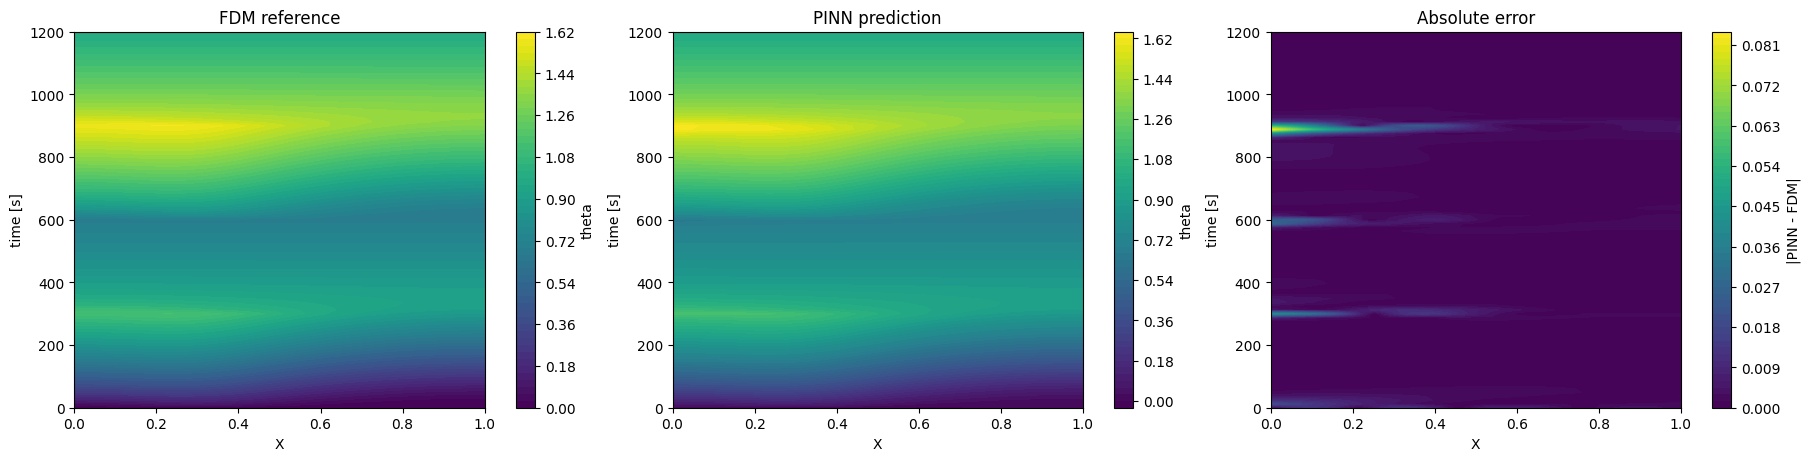

outputs/fdm_vs_pinn/fdm_pinn_full_field_contours.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

common_levels = 60

c0 = axes[0].contourf(x_values, time_seconds, theta_fdm, levels=common_levels)
axes[0].set_title("FDM reference")
axes[0].set_xlabel("X")
axes[0].set_ylabel("time [s]")
fig.colorbar(c0, ax=axes[0], label="theta")

c1 = axes[1].contourf(x_values, time_seconds, theta_pinn, levels=common_levels)
axes[1].set_title("PINN prediction")
axes[1].set_xlabel("X")
axes[1].set_ylabel("time [s]")
fig.colorbar(c1, ax=axes[1], label="theta")

c2 = axes[2].contourf(x_values, time_seconds, abs_error, levels=common_levels)
axes[2].set_title("Absolute error")
axes[2].set_xlabel("X")
axes[2].set_ylabel("time [s]")
fig.colorbar(c2, ax=axes[2], label="|PINN - FDM|")

fig_path = OUTPUT_DIR / "fdm_pinn_full_field_contours.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)


## 21. Time-slice comparison


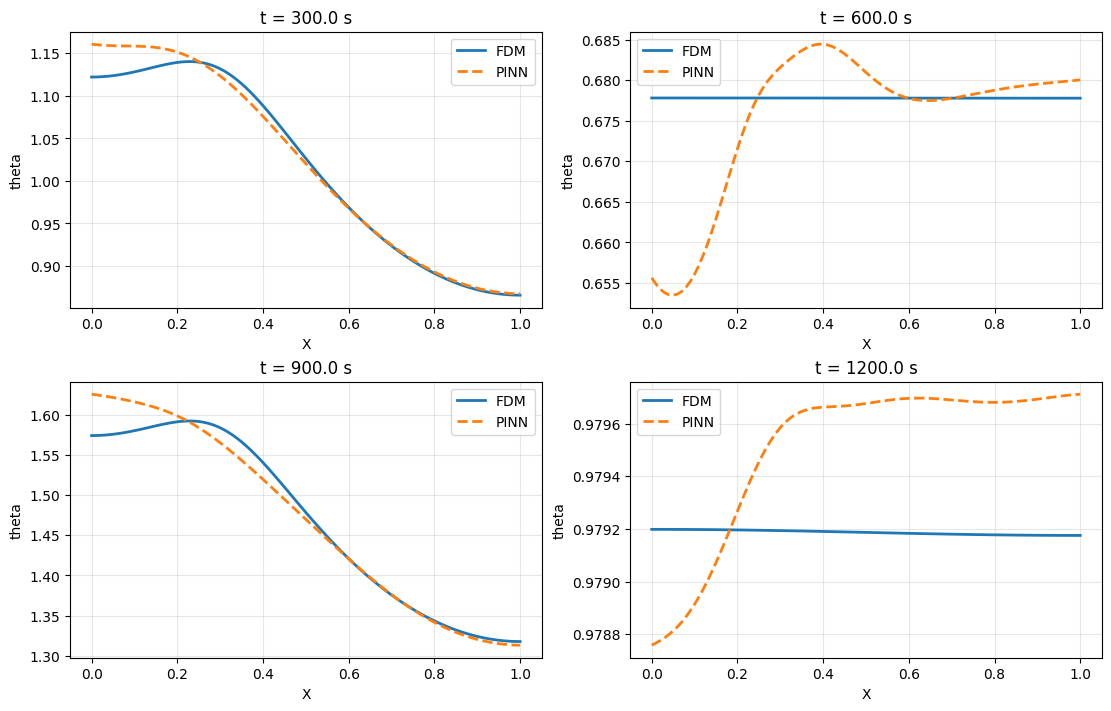

outputs/fdm_vs_pinn/fdm_pinn_time_slices.png


In [21]:
slice_times = [300.0, 600.0, 900.0, 1200.0]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes = axes.ravel()

for ax, target_time in zip(axes, slice_times):
    idx = int(np.argmin(np.abs(time_seconds - target_time)))
    ax.plot(x_values, theta_fdm[idx], label="FDM", linewidth=2)
    ax.plot(x_values, theta_pinn[idx], "--", label="PINN", linewidth=2)
    ax.set_title(f"t = {time_seconds[idx]:.1f} s")
    ax.set_xlabel("X")
    ax.set_ylabel("theta")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig_path = OUTPUT_DIR / "fdm_pinn_time_slices.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)


## 22. Sensor-location time histories


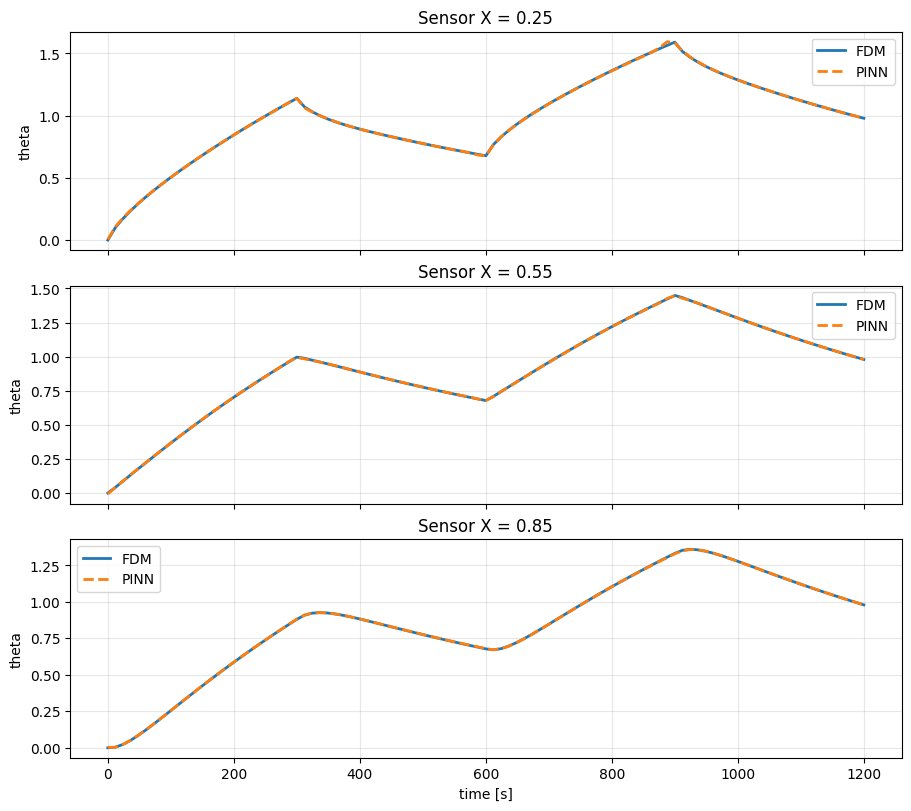

outputs/fdm_vs_pinn/fdm_pinn_sensor_histories.png


In [22]:
fig, axes = plt.subplots(len(SENSOR_X), 1, figsize=(9, 8), sharex=True, constrained_layout=True)

for ax, sensor_x in zip(axes, SENSOR_X):
    idx = int(round(sensor_x * (len(x_values) - 1)))
    ax.plot(time_seconds, theta_fdm[:, idx], label="FDM", linewidth=2)
    ax.plot(time_seconds, theta_pinn[:, idx], "--", label="PINN", linewidth=2)
    ax.set_ylabel("theta")
    ax.set_title(f"Sensor X = {sensor_x:.2f}")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("time [s]")

fig_path = OUTPUT_DIR / "fdm_pinn_sensor_histories.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)


## 23. Summary for report


In [23]:
with torch.no_grad():
    beta_learned = positive_parameter(raw_beta).item()
    s_learned = positive_parameter(raw_s).item()
    h_learned = physical_h_from_beta(torch.tensor(beta_learned)).item()
    q0_learned = physical_q0_from_s(torch.tensor(s_learned)).item()

print("FDM vs PINN full-field comparison")
print(f"iterations      : {ITERATIONS}")
print(f"network         : {args.depth} x {args.width}")
print(f"loss weights    : {LOSS_WEIGHTS}")
print(f"beta learned    : {beta_learned:.6f} / true {BETA_TRUE:.6f}")
print(f"S learned       : {s_learned:.6f} / true {S_TRUE:.6f}")
print(f"h learned       : {h_learned:.6f} / true {H_TRUE:.6f}")
print(f"q0 learned      : {q0_learned:.6e} / true {Q0_TRUE:.6e}")
print(f"MAE             : {mae:.6e}")
print(f"RMSE            : {rmse:.6e}")
print(f"Max error       : {max_error:.6e}")
print(f"Relative L2     : {rel_l2:.6e}")


FDM vs PINN full-field comparison
iterations      : 100000
network         : 3 x 32
loss weights    : [5, 10, 10, 10, 200]
beta learned    : 0.442169 / true 0.442193
S learned       : 5.370328 / true 5.389222
h learned       : 39.997864 / true 40.000000
q0 learned      : 7.971954e+04 / true 8.000000e+04
MAE             : 1.534292e-03
RMSE            : 4.503609e-03
Max error       : 8.390758e-02
Relative L2     : 4.604064e-03


## 24. Loss convergence curves


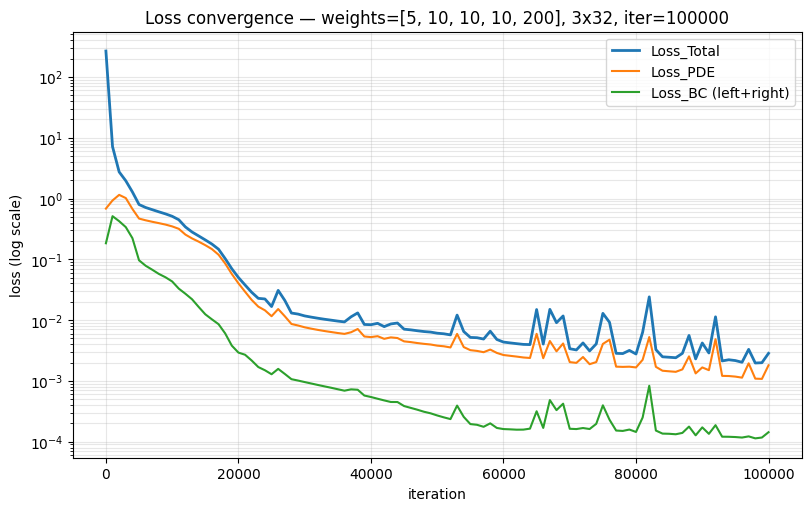

outputs/fdm_vs_pinn/loss_curves_total_pde_bc.png


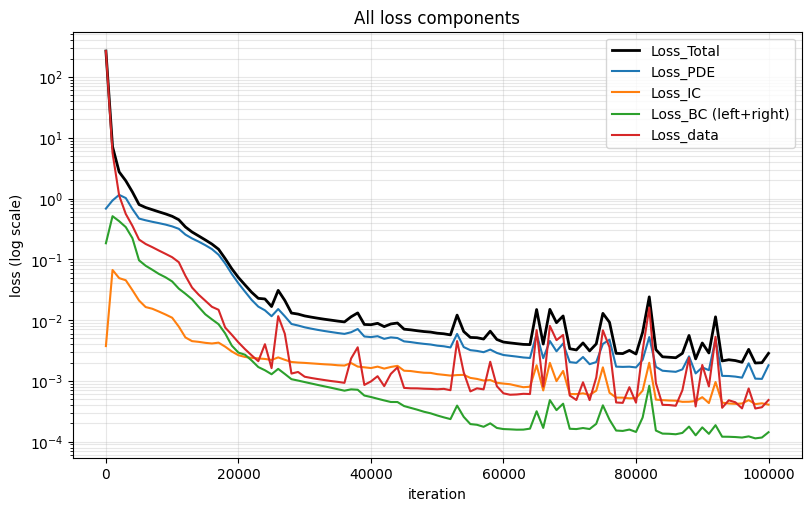

outputs/fdm_vs_pinn/loss_curves_all_components.png

Final training-loss components
step      : 100000
PDE       : 1.803632e-03
IC        : 4.058977e-04
BC l+r    : 1.428911e-04
data      : 4.840211e-04
Total     : 2.836443e-03
Total test: 7.764763e-03


In [24]:
steps = np.asarray(losshistory.steps)
loss_train = np.asarray(losshistory.loss_train)
loss_test = np.asarray(losshistory.loss_test) if losshistory.loss_test is not None else None

loss_pde = loss_train[:, 0]
loss_ic = loss_train[:, 1]
loss_bc = loss_train[:, 2] + loss_train[:, 3]
loss_data = loss_train[:, 4]
loss_total = loss_train.sum(axis=1)

eps = 1e-20
def _safe(arr):
    return np.maximum(arr, eps)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.semilogy(steps, _safe(loss_total), label="Loss_Total", linewidth=2)
ax.semilogy(steps, _safe(loss_pde), label="Loss_PDE", linewidth=1.5)
ax.semilogy(steps, _safe(loss_bc), label="Loss_BC (left+right)", linewidth=1.5)
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title(f"Loss convergence — weights={LOSS_WEIGHTS}, {args.depth}x{args.width}, iter={ITERATIONS}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig_path_main = OUTPUT_DIR / "loss_curves_total_pde_bc.png"
fig.savefig(fig_path_main, dpi=200)
plt.show()
print(fig_path_main)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.semilogy(steps, _safe(loss_total), label="Loss_Total", linewidth=2, color="black")
ax.semilogy(steps, _safe(loss_pde), label="Loss_PDE")
ax.semilogy(steps, _safe(loss_ic), label="Loss_IC")
ax.semilogy(steps, _safe(loss_bc), label="Loss_BC (left+right)")
ax.semilogy(steps, _safe(loss_data), label="Loss_data")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title("All loss components")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig_path_all = OUTPUT_DIR / "loss_curves_all_components.png"
fig.savefig(fig_path_all, dpi=200)
plt.show()
print(fig_path_all)

print()
print("Final training-loss components")
print(f"step      : {int(steps[-1])}")
print(f"PDE       : {loss_pde[-1]:.6e}")
print(f"IC        : {loss_ic[-1]:.6e}")
print(f"BC l+r    : {loss_bc[-1]:.6e}")
print(f"data      : {loss_data[-1]:.6e}")
print(f"Total     : {loss_total[-1]:.6e}")
if loss_test is not None:
    print(f"Total test: {loss_test.sum(axis=1)[-1]:.6e}")


## 25. Activation-function ablation: Tanh vs ReLU



========== activation = tanh ==========
Compiling model...
'compile' took 0.000224 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [6.82e-01, 3.73e-03, 7.28e-02, 1.11e-01, 2.66e+02]    [7.62e-01, 3.73e-03, 7.28e-02, 1.11e-01, 2.66e+02]    []  
500       [1.22e+00, 1.18e-01, 5.01e-01, 1.46e-02, 6.30e+00]    [1.01e+00, 1.18e-01, 5.01e-01, 1.46e-02, 6.30e+00]    []  
1000      [9.29e-01, 6.67e-02, 4.58e-01, 5.40e-02, 5.63e+00]    [7.56e-01, 6.67e-02, 4.58e-01, 5.40e-02, 5.63e+00]    []  
1500      [8.73e-01, 4.09e-02, 4.68e-01, 5.88e-02, 4.54e+00]    [7.20e-01, 4.09e-02, 4.68e-01, 5.88e-02, 4.54e+00]    []  
2000      [1.15e+00, 4.90e-02, 3.52e-01, 7.10e-02, 1.12e+00]    [9.78e-01, 4.90e-02, 3.52e-01, 7.10e-02, 1.12e+00]    []  
2500      [1.12e+00, 4.36e-02, 3.14e-01, 4.11e-02, 6.72e-01]    [9.21e-01, 4.36e-02, 3.14e-01, 4.11e-02, 6.72e-01]    []  
3000      [1.02e+00, 4.52e

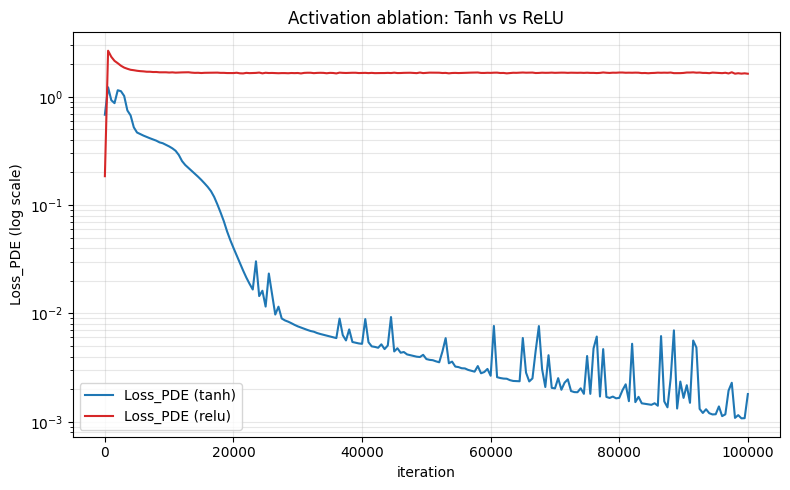

In [25]:
from types import SimpleNamespace
import copy

ABLATION_CFG = SimpleNamespace(
    iterations=100000,
    lr=1.0e-3,
    depth=3,
    width=32,
    num_domain=512,
    num_boundary=64,
    num_initial=64,
    num_test=200,
    sensor_time_points=41,
    display_every=500,
    seed=0,
)
ABLATION_LOSS_WEIGHTS = [5.0, 10.0, 10.0, 10.0, 200.0]


def build_model_with_activation(args, activation):
    raw_beta = dde.Variable(0.0)
    raw_s = dde.Variable(0.0)

    def pde(xtau, theta):
        theta_tau = dde.grad.jacobian(theta, xtau, i=0, j=1)
        theta_xx = dde.grad.hessian(theta, xtau, component=0, i=0, j=0)
        x = xtau[:, 0:1]
        tau = xtau[:, 1:2]
        beta = positive_parameter(raw_beta)
        s_value = positive_parameter(raw_s)
        return theta_tau - theta_xx + beta * theta - s_value * (current_profile(tau) ** 2) * gaussian_heat_source(x)

    def zero_numpy(x): return np.zeros((len(x), 1), dtype=np.float32)
    def on_initial(_, is_initial): return is_initial
    def on_left(x, on_b): return on_b and np.isclose(x[0], 0.0)
    def on_right(x, on_b): return on_b and np.isclose(x[0], 1.0)
    def adiabatic_bc(inp, out, _): return dde.grad.jacobian(out, inp, i=0, j=0)

    geom = dde.geometry.Interval(0.0, 1.0)
    time_domain = dde.geometry.TimeDomain(0.0, TAU_FINAL)
    geomtime = dde.geometry.GeometryXTime(geom, time_domain)

    ic = dde.icbc.IC(geomtime, zero_numpy, on_initial)
    left_bc = dde.icbc.OperatorBC(geomtime, adiabatic_bc, on_left)
    right_bc = dde.icbc.OperatorBC(geomtime, adiabatic_bc, on_right)
    sensor_xtau, sensor_theta = make_synthetic_sensor_data_numpy(args.sensor_time_points)
    sensor_bc = dde.icbc.PointSetBC(sensor_xtau, sensor_theta, component=0)

    data = dde.data.TimePDE(
        geomtime,
        pde,
        [ic, left_bc, right_bc, sensor_bc],
        num_domain=args.num_domain,
        num_boundary=args.num_boundary,
        num_initial=args.num_initial,
        num_test=args.num_test,
        train_distribution="Hammersley",
    )
    layer_sizes = [2] + [args.width] * args.depth + [1]
    net = dde.nn.FNN(layer_sizes, activation, "Glorot normal")
    return dde.Model(data, net), raw_beta, raw_s


def fdm_full_field(nx=101, n_time=121):
    """FDM reference used for full-field relative L2 error."""
    x = np.linspace(0.0, 1.0, nx)
    dx = x[1] - x[0]
    dtau = 0.4 * dx**2
    g_x = np.exp(-((x - X0) ** 2) / (2.0 * SIGMA_X**2))
    source_on = float(S_TRUE) * g_x
    beta_true = float(BETA_TRUE)

    save_tau = np.linspace(0.0, TAU_FINAL, n_time)
    field = np.zeros((n_time, nx), dtype=np.float64)
    theta = np.zeros(nx, dtype=np.float64)
    theta_xx = np.zeros(nx, dtype=np.float64)

    save_idx = 0
    n_steps = int(np.ceil(TAU_FINAL / dtau))
    for step in range(n_steps + 1):
        tau_now = step * dtau
        while save_idx < n_time and tau_now >= save_tau[save_idx]:
            field[save_idx] = theta
            save_idx += 1
        if tau_now >= TAU_FINAL:
            break
        theta_xx[1:-1] = (theta[2:] - 2 * theta[1:-1] + theta[:-2]) / dx**2
        theta_xx[0] = 2 * (theta[1] - theta[0]) / dx**2
        theta_xx[-1] = 2 * (theta[-2] - theta[-1]) / dx**2
        src = source_on if current_profile_scalar(tau_now) else 0.0
        step_dtau = min(dtau, TAU_FINAL - tau_now)
        theta = theta + step_dtau * (theta_xx - beta_true * theta + src)
    while save_idx < n_time:
        field[save_idx] = theta
        save_idx += 1
    return x, save_tau, field


def run_activation_case(activation):
    args_ablation = copy.copy(ABLATION_CFG)
    dde.config.set_random_seed(args_ablation.seed)
    model_ablation, raw_beta_ablation, raw_s_ablation = build_model_with_activation(args_ablation, activation)
    model_ablation.compile(
        "adam",
        lr=args_ablation.lr,
        loss_weights=ABLATION_LOSS_WEIGHTS,
        external_trainable_variables=[raw_beta_ablation, raw_s_ablation],
    )
    losshistory_ablation, train_state_ablation = model_ablation.train(
        iterations=args_ablation.iterations,
        display_every=args_ablation.display_every,
    )

    beta = positive_parameter(raw_beta_ablation).item()
    s_val = positive_parameter(raw_s_ablation).item()
    h_est = float(physical_h_from_beta(torch.as_tensor(beta)))
    q0_est = float(physical_q0_from_s(torch.as_tensor(s_val)))
    h_err = (h_est - H_TRUE) / H_TRUE * 100.0
    q0_err = (q0_est - Q0_TRUE) / Q0_TRUE * 100.0

    last_train = np.array(losshistory_ablation.loss_train[-1], dtype=float)
    loss_pde = last_train[0]

    x_grid, tau_grid, fdm = fdm_full_field()
    XX, TT = np.meshgrid(x_grid, tau_grid)
    pts = np.column_stack([XX.ravel(), TT.ravel()]).astype(np.float32)
    pinn = model_ablation.predict(pts).reshape(fdm.shape)
    rel_l2 = np.linalg.norm(pinn - fdm) / np.linalg.norm(fdm)

    return dict(
        activation=activation,
        h_est=h_est,
        q0_est=q0_est,
        h_err=h_err,
        q0_err=q0_err,
        loss_pde=loss_pde,
        rel_l2=rel_l2,
        losshistory=losshistory_ablation,
        train_loss=np.sum(losshistory_ablation.loss_train[-1]),
        test_loss=np.sum(losshistory_ablation.loss_test[-1]),
    )


results = {}
for act in ["tanh", "relu"]:
    print(f"\n========== activation = {act} ==========")
    results[act] = run_activation_case(act)

print("\n================ Activation ablation result ================")
header = f"{'Metric':<16}{'Tanh':>20}{'ReLU':>20}"
print(header)
print("-" * len(header))

def row(name, key, fmt):
    t = results["tanh"][key]
    r = results["relu"][key]
    print(f"{name:<16}{fmt.format(t):>20}{fmt.format(r):>20}")

row("Final Loss_PDE", "loss_pde", "{:.3e}")
row("Train loss", "train_loss", "{:.3e}")
row("Test loss", "test_loss", "{:.3e}")
row("h error (%)", "h_err", "{:+.3f}")
row("q0 error (%)", "q0_err", "{:+.3f}")
row("Rel L2", "rel_l2", "{:.3e}")
print(f"\ntrue values: h = {H_TRUE}, q0 = {Q0_TRUE:.3e}")

plt.figure(figsize=(8, 5))
for act, color in [("tanh", "tab:blue"), ("relu", "tab:red")]:
    lh = results[act]["losshistory"]
    steps = np.array(lh.steps)
    pde = np.array(lh.loss_train)[:, 0]
    plt.semilogy(steps, pde, color=color, label=f"Loss_PDE ({act})")
plt.xlabel("iteration")
plt.ylabel("Loss_PDE (log scale)")
plt.title("Activation ablation: Tanh vs ReLU")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("activation_ablation_tanh_vs_relu.png", dpi=150)
plt.show()
